# Introduction

This Jupyter notebook, with code written in the Python language, contains the calculations of all results presented in Section 3 of our article. First we compare results for correct and incorrect implementations of the finite-population model. Then we turn to the infinite-population model.

Only the top-level code is shown here. One need not read it to follow the presentation.  The code is profusely commented, and should be understandable by readers with general knowlege of object-oriented programming. There are two levels of commentary:
```python
    """
    This is a high-level description of what...
    """

    # This is a low-level explanation of how...
```
All of the modules run in the following cell are presented, and furthermore tested, in Supporting Materials 2.

In [1]:
%matplotlib notebook
"""
Run the supporting modules without listing the source code.
"""
%run    ./Code/bs.py
%run -i ./Code/rates.py
%run -i ./Code/derivative.py
%run -i ./Code/probability.py
%run -i ./Code/bs_plot.py
"""
Figures in this notebook are non-interactive.
"""
plt.interactive(False)
"""
Subdirectory ./SM1data contains the graphics generated by this notebook.
"""
DIR = './SM1data/'
ensure_directory_exists(DIR)
"""
Indicate when this code cell was last executed.
"""
from datetime import datetime
print("Time stamp:", datetime.now())

Time stamp: 2020-03-03 06:37:38.385346


# Results for the finite-population model

What Basener and Sanford take to be a realistic finite-population model is a modification of their infinite-population model. In the modified model, the frequency of a class changes continuously according to the master equation if the relative frequency of the class is at least $10^{-9}\!.$ Otherwise, the frequency of the class is defined to be zero. That is to say, the derivative is undefined for a subthreshold frequency, which drops instantaneously to zero. Basener and Sanford fail to note the consequence that frequencies of zero remain zero forever. To put it intuitively, a frequency of zero cannot rise instantaneously to threshold, and hence is continuously reset to zero. In effect, the derivative of a frequency of zero is zero.

In Basener's software implementation of the finite-population model, all frequencies change according to the master equation. Furthermore, zeroed frequencies are given a year to rise to threshold. Here we show that these implementational errors hide the fact that the finite-population model is unrealistic in the extreme. (Various other defects of Basener's software are addressed in Supporting Materials 3.)

## Numerical solution of the finite-population model

In Section 4 of their article, Basener and Sanford express the master equation as

$$\mathbf{P}^\prime\!(t) = W \mathbf{P}(t).$$

That is, the product of the square matrix $W$ and the column vector $\mathbf{P}(t)$ of frequencies at time $t$ is the vector of derivatives for time $t.$ Furthermore,

$$\frac{\text{d}P_i(t)}{\text{d}t} = P^\prime_i\!(t) = W_{i,*} \mathbf{P}(t),$$

where $W_{i,*}$ is the $i$-th row of $W.$ Given the initial frequencies $\mathbf{P}(0),$ one may use the Euler forward method of numerical integration to solve for frequencies at later times: set the initial solution $\mathbf{s}_0 = \mathbf{P}(0),$ and then iterate

$$\mathbf{s}_{n+1} \leftarrow \mathbf{s}_{n} + h \:\! W \mathbf{s}_n,$$

where scalar $h > 0$ is the step size, and $\mathbf{s}_n$ is the solution for frequencies $\mathbf{P}(n\:\!h).$ 

To solve for frequencies in the finite-population model, Basener tacitly sets the step size to one year, and extends the Euler forward method to zero elements of $\mathbf{s}_{n+1}$ that fall below threshold:

\begin{align*}
   \mathbf{s}_{n+1} &\leftarrow \mathbf{s}_{n} + h \:\! W \mathbf{s}_n \\
   s_{n+1,i} &\leftarrow 0 \text{ for all } i \text{ such that } s_{n+1,i} / \text{sum}(\mathbf{s}_{n+1}) < 10^{-9}  ,
\end{align*}


where $\text{sum}(\mathbf{v}) := \sum_i v_i.$ (Basener erroneously puts $\text{max}(\cdot)$ in place of $\text{sum}(\cdot)$ in the calculation of relative frequencies.) Considering that the derivatives of relative frequencies are bounded, it is easy to see that the calculated relative frequency of a class cannot rise from zero to $10^{-9}$ in a single step if the step size $h$ is sufficiently small. Thus, in the continuous-time system approximated by iteration of the two steps above, a frequency of zero never changes.

We further modify the solution procedure, copying elements of zero from $\mathbf{s}_n$ to $\mathbf{s}_{n+1},$ and restricting the numerical integration to classes for which the calculated frequencies are positive. That is,


\begin{align*}
   \mathbf{s}_{n+1} &\gets \mathbf{s}_{n} \\
   {s}_{n+1,i} &\gets {s}_{n,i} + h \:\! W_{i,*} \mathbf{s}_n  \text{ for all } i \text{ such that } s_{n,i} > 0 \\
   s_{n+1,i} &\leftarrow 0 \text{ for all } i \text{ such that } s_{n+1,i} / \text{sum}(\mathbf{s}_{n+1}) < 10^{-9} .
\end{align*}


This procedure is implemented by the `step` method of the Python class `ModifiedEuler`, which is defined in the following code cell. For consistency, the initialization method of the class zeroes subthreshold frequencies in the given initial solution:

\begin{align*}
\mathbf{s}_0 &\gets \mathbf{P}(0) \\
s_{0,i} &\gets 0 \text{ for all } i \text{ such that } s_{0,i} / \text{sum}(\mathbf{s}_{0}) < 10^{-9} .
\end{align*}

In [12]:
# %load './Code/modified_euler.py'
class Euler(object):
    """
    A solver for frequencies in the infinite-population model.
    
    A modification of the Euler forward method of numerical integration
    is applied. Solutions for frequencies are set to zero when they fall
    below a given threshold, and subsequently are held at zero. If the
    threshold is zero, then the solutions are precisely those that would
    be obtained by the Euler forward method:
    
        http://mathworld.wolfram.com/EulerForwardMethod.html
        
    Only end-of-year solutions are stored, beginning with the solution
    for year 0 (derived from the given initial frequencies).
    
    ASSUMPTION: Frequencies fall below threshold only at the tail ends
    of the frequency distribution.
    
    The solver is run by calling this object. Each call extends the 
    solutions by a given number of years. The end-of-year solutions are
    retrieved by indexing this object.
    """
    @classmethod
    def bias_exponents(cls, solution, max_exponent=512):
        """
        Scales the `solution` array by an integer power of 2.
        
        On return, the internal representatiom of the maximum element of
        `solution` has `max_exponent` as its exponent. There is no change
        in the mantissas of the elements, and hence there is no loss of
        precision.
        """
        _, current_max = frexp(solution.max())
        solution *= 2.0 ** (max_exponent - current_max)
        
    def __init__(self, derivative, steps_per_year, initial_freqs):
        """
        Initialize the solver.
        
        The `derivative` operator is an instance of class Derivative.
        When the solver is run, there are `steps_per_year` integration
        steps in each year, each with the step size set to the reciprocal
        of `steps_per_year`. To ensure accuracy, the number of steps per
        year (and its reciprocal) should be an integer power of 2.
        
        WRONG: The solution for year 0 is `initial_freqs` with frequencies less
        than `threshold` times the sum of `initial_freqs` set to zero.
        The given `threshold` is used similarly in each integration step.
        """
        self.W = derivative
        self.steps_per_year = steps_per_year
        self.step_size = 1 / steps_per_year
        #
        # Array `s` always contains the current solution for frequencies
        # of classes. The base type of `s` is that of `initial_value`.
        self.s = initial_freqs + 0
        Euler.bias_exponents(self.s)
        self.initialize_solution()
        #
        # Array `solutions` contains the solutions for end-of-year
        # relative frequencies of classes. The base type is float. There
        # is one row for each year.
        self.n_solutions = 1
        self.solutions = np.empty((self.n_solutions, len(self.s)))
        self.solutions[0] = self.s / fsum(self.s)

    def initialize_solution(self):
        """
        Do nothing. The initial solution is the given initial frequencies.
        """
        self.s = initial_freqs
    
    def step(self):
        """
        Updates all elements of the solution in an integration step.
        """
        self.s += self.step_size * self.W(None, self.s)
        
    def __call__(self, n_years=1000):
        """
        Solve for `n_years` end-of-year relative frequencies.
        """
        # Extend the `solutions` array to hold an additional `n_years`
        # solutions for end-of-year relative frequencies.
        self._extend_storage(n_years)
        #
        for _ in range(n_years):
            # Scale current solution in order to avoid overflow and
            # underflow in calculations.
            Euler.bias_exponents(self.s)
            #
            # Perform `steps_per_year` numerical integration steps.
            for _ in range(self.steps_per_year):
                self.step()
            #
            # Store the solution for end-of-year relative frequencies.
            self.solutions[self.n_solutions] = self.s / fsum(self.s)
            self.n_solutions += 1

    def __getitem__(self, which):
        """
        Returns the result of indexing solutions by `which`.
        """
        return self.solutions[which]

    def __len__(self):
        """
        Returns the number of stored solutions (one per year).
        """
        return len(self.solutions)

    def _extend_storage(self, n):
        """
        Allocate storage for solutions for an additional `n` years.
        """
        rows, cols = self.solutions.shape
        new = np.zeros((rows+n, cols), dtype=float)
        new[:rows] = self.solutions
        self.solutions = new

            
class ModifiedEuler(Euler):
    def __init__(self, derivative, steps_per_year, initial_freqs,
                       threshold=1e-9):
        """
        Initialize the solver.
        
        [The first three params...] 
        The `threshold` is the minimum relative frequency [...]
        """
        self.threshold = threshold
        # Invoke the initializer method of the superclass.
        super().__init__(derivative, steps_per_year, initial_freqs)
        
    def initialize_solution(self):
        """
        Zeroes subthreshold elements in the tails of the initial solution.
        """
        left, right = trim(self.s, self.threshold * self.s.sum())
        #
        # Slice `include` indexes nonzero elements of the solution.
        self.include = slice(left, len(self.s) - right)

    def step(self):
        """
        Updates nonzero elements of the solution in an integration step.
        """
        # Nonzero elements of the solution are indexed by slice `include`.
        include = self.include
        included = self.s[include]
        #
        # Only the nonzero elements of the solution are modified.
        included += self.step_size * self.W(None, included, include)
        #
        # Zero `included` elements that fall below threshold.
        l, r = trim(included, self.threshold * included.sum())
        #
        # Exclude newly zeroed elements from the `include` slice.
        self.include = slice(include.start + l, include.stop - r)

        
class PoorlyModifiedEuler(Euler):
    def __init__(self, derivative, steps_per_year, initial_freqs,
                       threshold=1e-9, margin=2):
        """
        Initialize the solver.
        
        [The first three params...] 
        The `threshold` is the minimum relative frequency ...
        The `margin` is ...
        """
        self.threshold = threshold
        self.margin = margin
        # Invoke the initializer method of the superclass.
        super().__init__(derivative, steps_per_year, initial_freqs)
     
    def initialize_solution(self):
        """
        Zeroes subthreshold elements in the tails of the initial solution.
        """
        trim(self.s, self.threshold * self.s.sum())
        #
        # Slice `include` indexes the solutions to be updated in the next
        # integration step. All solutions are updated in the first step.
        self.include = slice(0, len(self.s))

    def step(self):
        """
        Updates some elements of the solution in an integration step.
        
        All positive elements are updated, along with some zero elements
        to the immediate left and right of the positive elements. Updated
        elements that fall below threshold are zeroed. In general, the
        first and the last of the updated elements should remain zero.
        """
        # The `included` elements of the solution are those that stand a
        # chance of being greater than or equal to the threshold when
        # updated in an integration step.
        include = self.include
        included = self.s[include]
        #
        # Update the included elements of the solution.
        included += self.step_size * self.W(None, included, include)
        #
        # Zero included elements that fall below threshold.
        left, right = trim(included, self.threshold * included.sum())
        #
        # If `self.margin` is set large enough, then the leftmost and
        # rightmost elements of `included` generally should be zero.
        lower_error = included[0] != 0 and include.start != 0
        upper_error = included[-1] != 0 and include.stop != len(self.s)
        if lower_error or upper_error:
            raise exception('margin parameter is set too small')
        #
        # In the next integration step, `margin` elements to the left and
        # right of the positive elements will be updated along with the
        # positive elements.
        start = max(0, include.start + left - self.margin)
        stop = min(len(self.s), include.stop - right + self.margin)
        self.include = slice(start, stop)

## Run the good and poor solvers

What we refer to as the good solver and the poor solver are, respectively, instances of the class `ModifiedEuler` and the class `PoorlyModifiedEuler`. The solvers are identically initialized. 

**NEED MORE.** We are following Section 5.4 of Basener and Sanford. Initial frequencies are obtained by binning a normal distribution with mean 0.044 and standard deviation 0.005. The upper limit on fitness is 0.1, and the number of bins (classes) is 401. The distribution of probability over mutational effects...

In [13]:
def finite_setup(steps_per_year=2**10, threshold=1e-9):
    """
    Returns initialized solvers along with rates.
    """    
    max_birth_rate = mp_float('0.2')
    rates = Rates(max_birth_rate, death='0.1')
    #
    # Define the derivative operator in terms of the distribution of
    # probability over mutational effects. The distribution is a mixture
    # of a Gamma distribution and its reflection, with weight 1e-3 of
    # the distribution over positive effects, as in Section 5.4 of
    # Basener and Sanford.
    p = bs_mutation_probabilities(rates, beneficial_weight='1e-3')
    W = Derivative(p, rates)
    #
    # Obtain the frequency distribution of the initial population by
    # binning a normal probability distribution. The parameters of the
    # distribution come from Section 5 of Basener and Sanford.
    initial_freqs = bs_initial_frequencies(rates)
    ModifiedEuler.bias_exponents(initial_freqs)
    initial_freqs = convert(initial_freqs, float)
    #
    # Return solver in given class.
    args = (W, steps_per_year, initial_freqs, threshold)
    return (ModifiedEuler(*args), PoorlyModifiedEuler(*args), rates)

good_solver, poor_solver, rates = finite_setup(steps_per_year=2**5)

In [20]:
%%time
"""
Run the good solver.
""" 
good_solver(n_years=12000)

CPU times: user 13.5 s, sys: 213 ms, total: 13.7 s
Wall time: 12.7 s


In [18]:
%%time
"""
Run the poor solver.
""" 
poor_solver(n_years=27000)

CPU times: user 1min 35s, sys: 5.04 s, total: 1min 40s
Wall time: 30.5 s


**How small must the step size be to prevent relative frequency of zero from rising to threshold?** Exploring integer powers of 2:

In [87]:
i = good_solver.include.start - 1
h = 2**-24
s=good_solver.s + h * np.dot(good_solver.W.W, good_solver.s)
good_solver.s[i], s[i]/fsum(s)

(0.0, 5.530822611984742e-10)

### Check for convergence

In [21]:
"""
Output the maximum absolute error of the solution for an earlier year
relative to the solution for the last year. The earlier year is 1000
years prior to the last year of the run.
"""
print('Convergence checks (maximum absolute relative error)')
print('\tGood solver:', 
      maximum_absolute_relative_error(good_solver[-1001], good_solver[-1]))
print('\tPoor solver:', 
      maximum_absolute_relative_error(poor_solver[-1001], poor_solver[-1]))

Convergence checks (maximum absolute relative error)
	Good solver: 4.1044681595426916e-15
	Poor solver: 7.512211313859334e-15


### Plot solutions in selected years

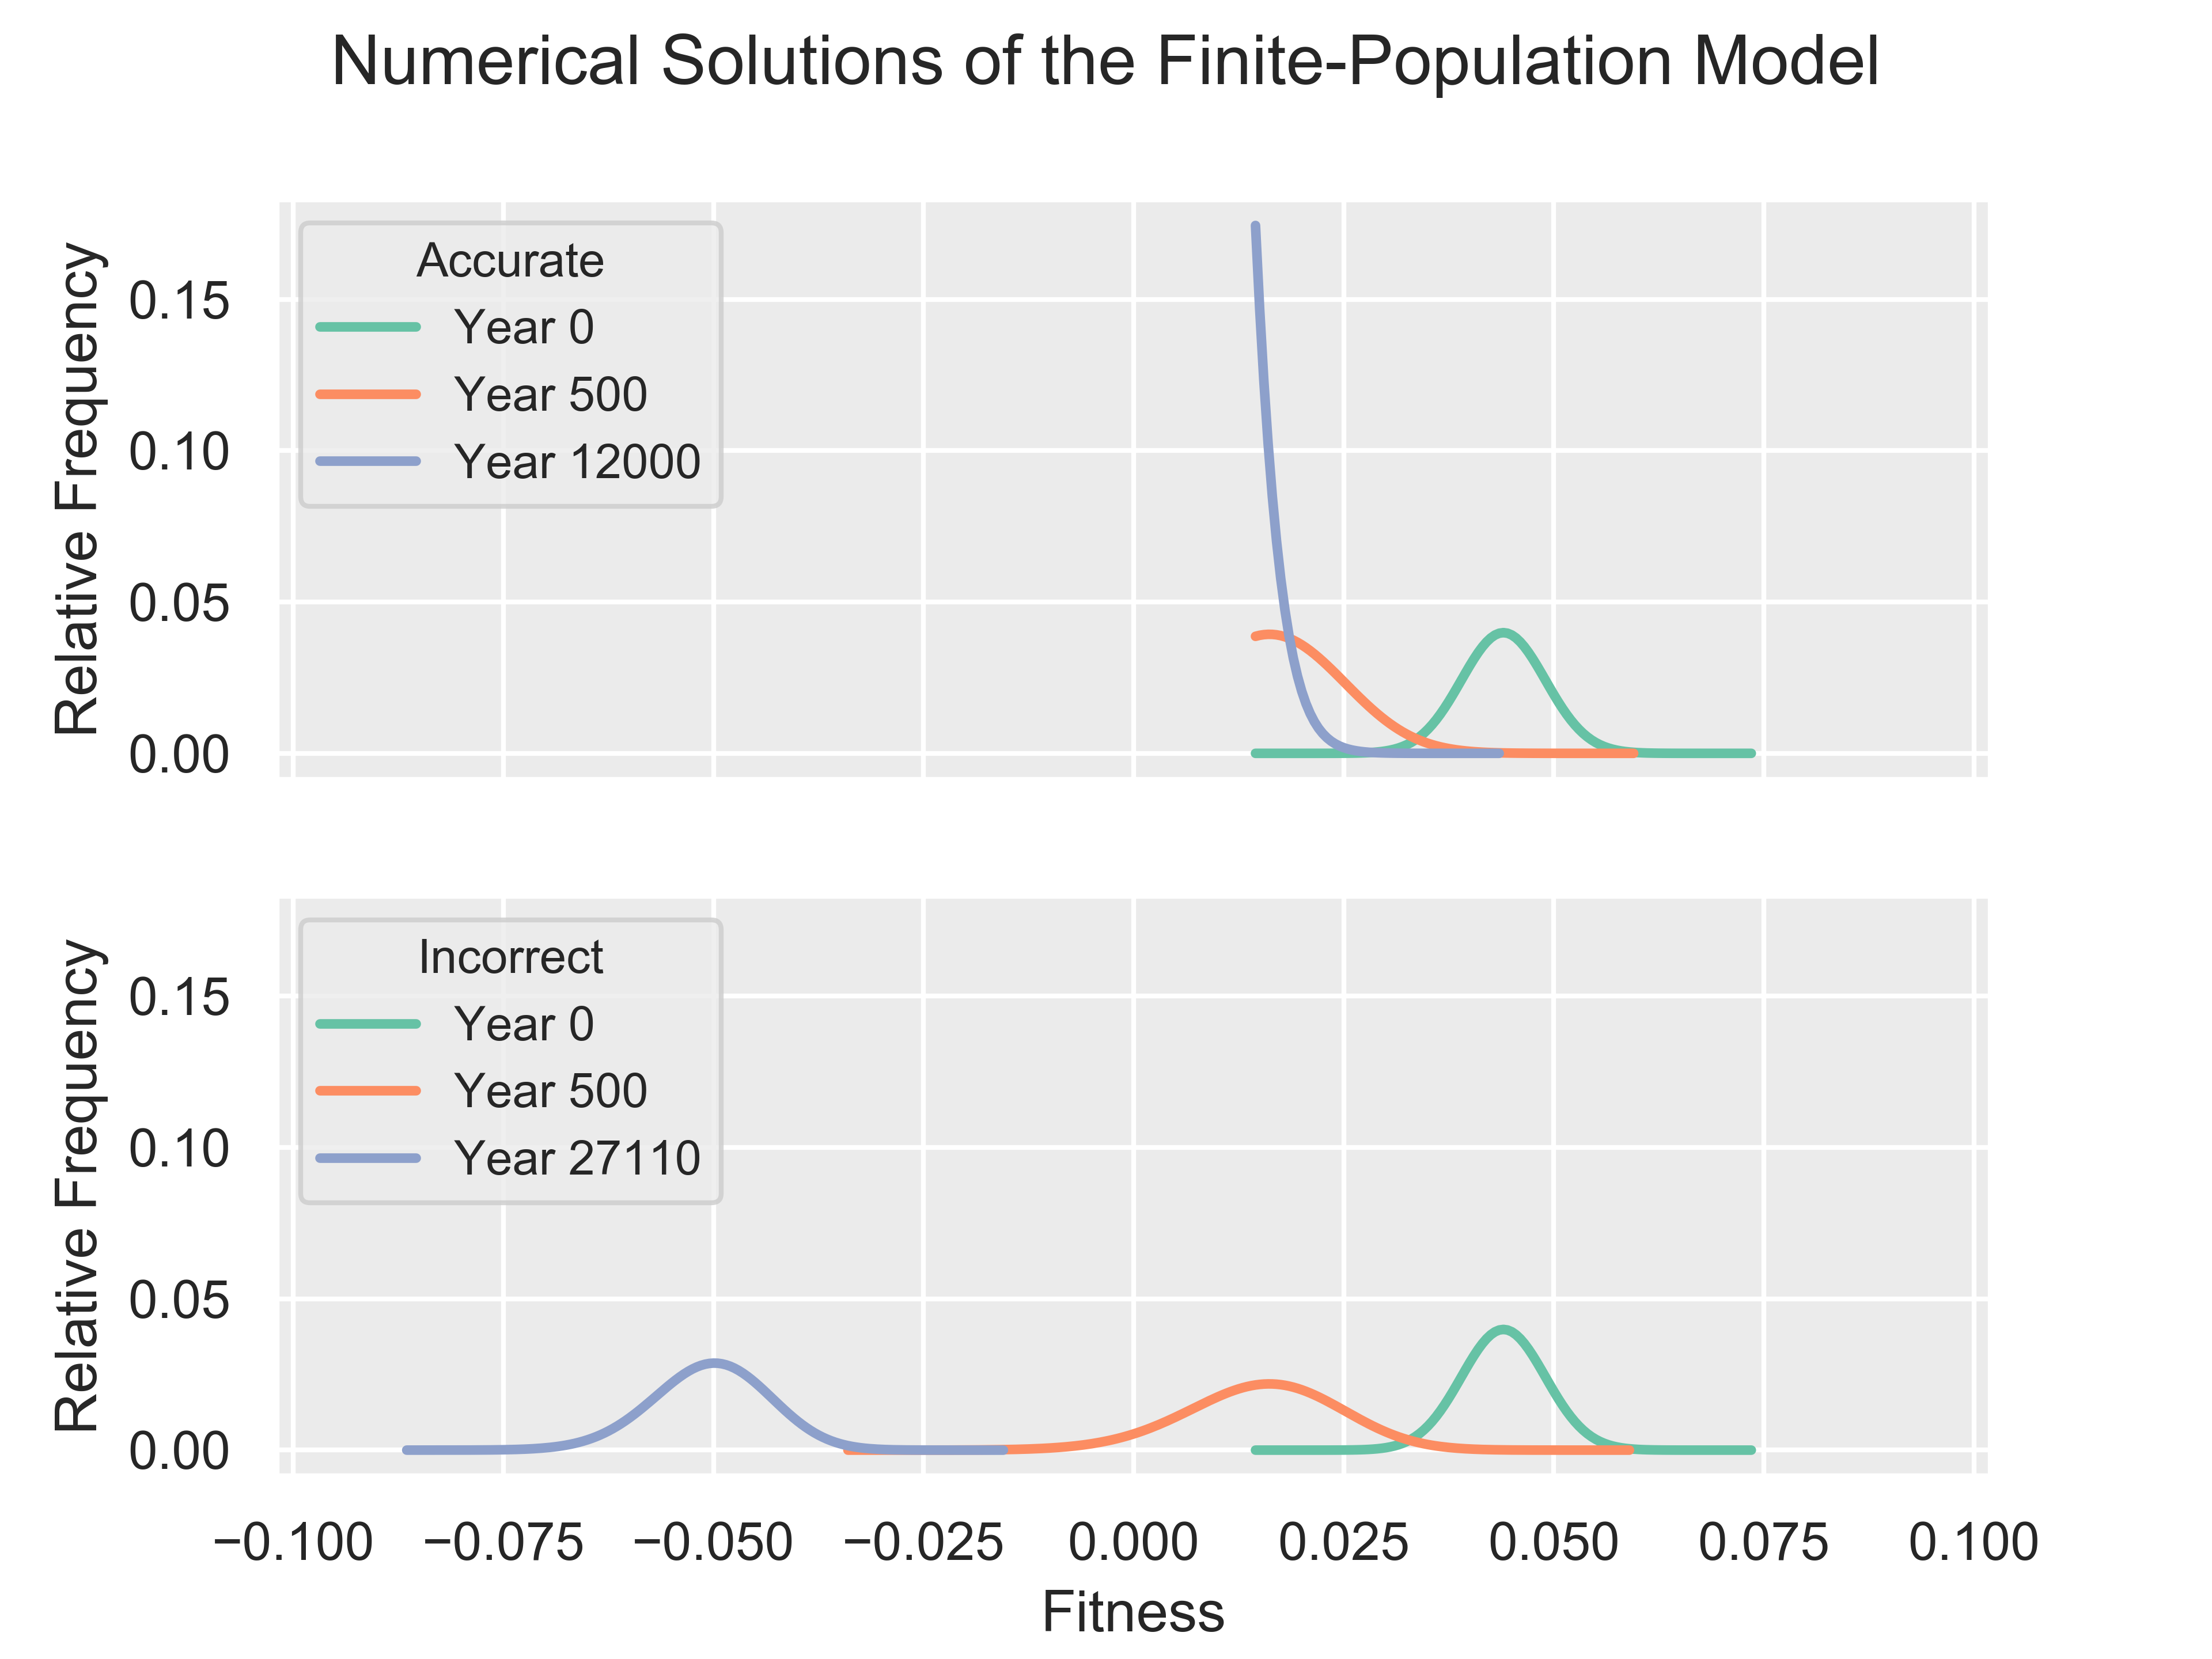

In [80]:
%run -i ./Code/bs_plot.py

def exp_latex(value):
    base = 2
    log = round(math.log(value, base))
    if value != base**log:
        base = 10
        log = round(math.log(value, base))
    string = '${}^{}{}{}$'.format(base, '{', log, '}')
    return string

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True)
fig.suptitle('Numerical Solutions of the Finite-Population Model')
bs_plot(good_solver, rates.fitness, 500, ax=ax1)
#ax1.set_title('Accurate Solutions of the Finite-Population Model')
ax1.set_xlim(-0.102, 0.102)
ax1.set_xlabel(None)
ax1.legend(loc='upper left', fontsize='small', title='Accurate',
           title_fontsize='small')
#save_and_display(fig, DIR + 'Fig1.png')


fig, ax = bs_plot(poor_solver, rates.fitness, 500, ax=ax2)
t = 'Categorically Incorrect Solutions of the Finite-Population Model'
#ax2.set_title(t)
ax2.set_xlim(-0.102, 0.102)
ax2.legend(loc='upper left', fontsize='small', title='Incorrect',
           title_fontsize='small')
save_and_display(fig, DIR + 'Fig2.png')

## FTNSwM does not hold for finite-pop model

**Ignore this for now**

\begin{align}
    \frac{\text{d}\bar{m}}{\text{d}t}
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\left(\sum_j b_j f_{ij} P_j\right) - b_i P_i\right) (m_i - \bar{m}) \nonumber \\
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\frac{\text{d}P_i}{\text{d}t} - m_i P_i\right) (m_i - \bar{m}) 
    \label{eq:FTNSwM}
\end{align}

In [9]:
def theorem_value(frequencies, derivatives, fitnesses):
    norm = fsum(frequencies)
    mean, var = mean_var(frequencies, fitnesses)
    rate_differences = derivatives - fitnesses * frequencies
    fitness_deviates = fitnesses - mean
    return var + fsum(rate_differences * fitness_deviates) / norm

def check_theorem(frequencies, derivative, fitnesses, delta_t=2**-20,
                  threshold=2**-20):
    derivatives = derivative(None, frequencies)
    theorem = theorem_value(frequencies, derivatives, fitnesses)
    mean = mp_mean(frequencies, fitnesses)
    new_freqs = frequencies + time_step * derivatives
    new_freqs[new_freqs < threshold * fsum(new_freqs)] = 0
    new_mean = mp_mean(new_freqs, fitnesses)
    return {'theorem' : thm, 'actual' : (new_mean - mean) / delta_t}    

In [10]:
def SAVE():
    with mp.workdps(600):
        max_birth_rate = mp.mpf('0.2')
        rates = Rates(max_birth_rate)
        fitnesses = rates.fitness
        mutation_probs = np.empty_like(rates.effects, dtype=mp.mpf)
        mutation_probs[:] = mp.mpf(0)
        mutation_probs[len(mutation_probs) // 2 - 1] = mp.mpf(1)
        freqs = np.empty_like(fitnesses)
        freqs[:] = mp.mpf(0)
        freqs[-1] = mp.mpf(1)
        mean = mp_mean(freqs, fitnesses)
        derivative = Derivative(mutation_probs, rates)
        dt = mp.mpf('2') ** -500
        threshold = 0
        new_freqs = freqs + dt * derivative(None, freqs)
        new_freqs[new_freqs < threshold * mp.fsum(new_freqs)] = 0
        new_mean = mp_mean(new_freqs, fitnesses)
        print((new_mean - mean) / dt)
        print(theorem_value(freqs, derivative(None, freqs), fitnesses))

**Illustration that poor solver is OK with small step size.**

In [11]:
popsize = 2**20
threshold = 1 / popsize
steps_per_year = popsize // 64
good_solver, poor_solver, rates = finite_setup(steps_per_year, threshold)

In [18]:
%%time
"""
Run the good solver.
""" 
# good_solver(n_years=12000) 
good_solver(n_years=800) #2400 total

CPU times: user 5min 13s, sys: 1.97 s, total: 5min 15s
Wall time: 5min 16s


In [19]:
%%time
"""
Run the poor solver.
""" 
# poor_solver(n_years=27000)
poor_solver(n_years=800)

CPU times: user 7min 3s, sys: 3.21 s, total: 7min 6s
Wall time: 7min 10s


In [9]:
slice_to_support(poor_solver.s), slice_to_support(poor_solver.solutions[0])

(slice(0, 401, None), slice(0, 401, None))

# The infinite-population model

In [11]:
# %load ./Code/equilibria.py
class Equilibria(object):
    """
    NEED
    
    ... rows corresponding to probability distributions over mutational
    effects, and columns corresponding to upper limits on fitness.
    """
    bin_width = mp_float('5e-4')
    
    def __init__(self, comp_cdf, weights, weight_labels, fitness_limits,
                       death_rate='0.1'):
        """
        NEED
        """
        w = Equilibria.bin_width
        d = mp_float(death_rate)
        self.death_rate = d
        self.weight_labels = np.array(weight_labels)
        self.limits = np.array(fitness_limits)
        birth_rate_limits = mp_float(fitness_limits) + d
        self.rates = [Rates(limit, d, w) for limit in birth_rate_limits]
        nbins = np.max([len(r.effects) for r in self.rates])
        self.probs = [binned_mixture(comp_cdf, nbins, weight, w)
                          for weight in weights]
        #
        # Create arrays to hold results, with rows corresponding to
        # probability distributions over mutational effects, and columns
        # corresponding to upper limits on fitness.
        m = len(self.probs)
        n = len(self.rates)
        self.eq = np.empty((m, n), dtype=object)
        self.mean = np.empty((m, n))
        self.var = np.empty((m, n))
        #
        # There is one slope for each row, obtained by regression of
        # means on variances (through the origin).
        self.slope = np.empty(m)
        #
        # Now fill the arrays with results.
        self._calculate()
        
    def _calculate(self):
        # Calculate equilibria along with means/variances of fitnesses.
        mean = self.mean
        var = self.var
        eq = self.eq
        for i, probs in enumerate(self.probs):
            for j, rates in enumerate(self.rates):
                trim = (len(probs) - len(rates.effects)) // 2
                p = probs[trim : len(probs)-trim]
                d = Derivative(p / fsum(p), rates, basetype=float)
                eq[i,j] = d.equilibrium()
                mean[i,j], var[i,j] = mean_var(eq[i,j], rates.fitness)
            self.slope[i] = regress_through_origin(var[i], mean[i])

    def plot_stats(self, supertitle='SUPER', title='TITLE'):
        """
        NEED
        """
        # Set up two axis systems, one for means, the other for variances.
        sns.set_palette(sns.color_palette("Set2", len(self.mean)))
        fig, ax_mean = plt.subplots()
        ax_var = ax_mean.twinx()
        ax_var.grid(False)
        ax_mean.grid(True, zorder=0)
        #
        # Plot the means and scaled variances as functions of the upper
        # limit on fitness, row by row. Each row corresponds to a
        # distribution of probability over mutational effects. For each
        # row, the variances are scaled by the slope obtained by
        # regression of the means on the variances (through the origin).
        limits = [r.fitness[-1] for r in self.rates]
        z = zip(self.mean, self.var, self.slope, self.weight_labels)
        for m, v, s, label in z:
            ax_mean.plot(limits, m, label=label)
            ax_var.plot(limits, s*v, label=label, marker='o', ls='none')
        #
        # Add titles, axis labels, and legends.
        fig.suptitle(supertitle)
        ax_mean.set_title(title)
        ax_mean.set_xlabel('Upper Limit on Fitness')
        ax_mean.set_ylabel('Mean Fitness at Equilibrium')
        ax_var.set_ylabel('Scaled Variance in Fitness at Equilibrium')
        ax_mean.legend(title='Mean', loc='upper left')
        ax_var.legend(title='Variance', loc='lower right')
        #
        self.fig, self.ax_mean, self.ax_var = fig, ax_mean, ax_var
    
    def _begin_plot_curves(self, eq):
        sns.set_palette(sns.color_palette("Set2", len(eq)))
        self.fig, self.ax = plt.subplots()
        self.lines = np.empty(len(eq), dtype=object)
        max_y = max([e.max() for e in eq])
        self.ax.set_ylim([-0.0003, 1.05 * max_y])
        
    def plot_column(self, j):
        eq = self.eq[:, j]
        fitness = self.rates[j].fitness
        variable_name = 'Beneficial Weight'
        constant_name = 'Upper Limit on Fitness {}'.format(fitness[-1])
        self._begin_plot_curves(eq)
        for i in range(len(eq)):
            label = '{}'.format(self.weight_labels[i])
            self.lines[i], = plt.plot(fitness, eq[i], label=label)
        self._finish_plot_curves(variable_name, constant_name)

    def plot_row(self, i):
        eq = self.eq[i, :]
        variable_name = 'Fitness Limit'
        constant_name = 'Beneficial Effects Weight {}'
        constant_name = constant_name.format(self.weight_labels[i])
        self._begin_plot_curves(eq)
        for j in range(len(eq)):
            label = '{}'.format(self.limits[j])
            fitness = self.rates[j].fitness
            self.lines[j], = plt.plot(fitness, eq[j], label=label)
            self.lines[j].set_zorder(100 - j)
        self._finish_plot_curves(variable_name, constant_name)

    def _finish_plot_curves(self, variable_name, constant_name):
        self.ax.set_ylabel('Relative Frequency')
        self.ax.set_xlabel('Fitness')
        supertitle = 'Dependence of Equilibrium Distribution on '
        self.fig.suptitle(supertitle + variable_name)
        self.ax.set_title('Infinite Population, ' + constant_name)
        self.ax.legend(title=variable_name, loc='best')
        self.ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    
    def save_and_display(self, filename):
        """
        Save figure to disk, display it, and close the plot.
        """
        save_and_display(self.fig, filename)

    def __getitem__(self, which):
        """
        Returns equilibrium along with mean and variance of fitness.
        """
        return self.eq[which], self.mean[which], self.var[which]

In [11]:
%%time
fitness_limits = ['0.025', '0.050', '0.075', '0.100',
                  '0.125', '0.150', '0.175', '0.200']
log_weights = ['-3', '-6', '-9', '-12']
weights = ['1e{}'.format(w) for w in log_weights]
labels = ['$\gamma = 10^{' + '{}'.format(w) + '}$' for w in log_weights]

eq = Equilibria(gamma_ccdf, weights, labels, fitness_limits, '0.1')

./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.0588012949705316e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4535882824639324e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 8.142736290237168e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.170261018483468e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 8.842276087326369e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.5341302265090332e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.47316112889744e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 9.095048828124903e-16
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4681958489170332e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.9572469729797092e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.1525444131555095e-15
./Code/bs_plot.py:122: UserWarning: equilibrium relative err

CPU times: user 25min 1s, sys: 45.8 s, total: 25min 46s
Wall time: 7min 35s


./Code/bs_plot.py:122: UserWarning: equilibrium relative error 1.4798496151064683e-15


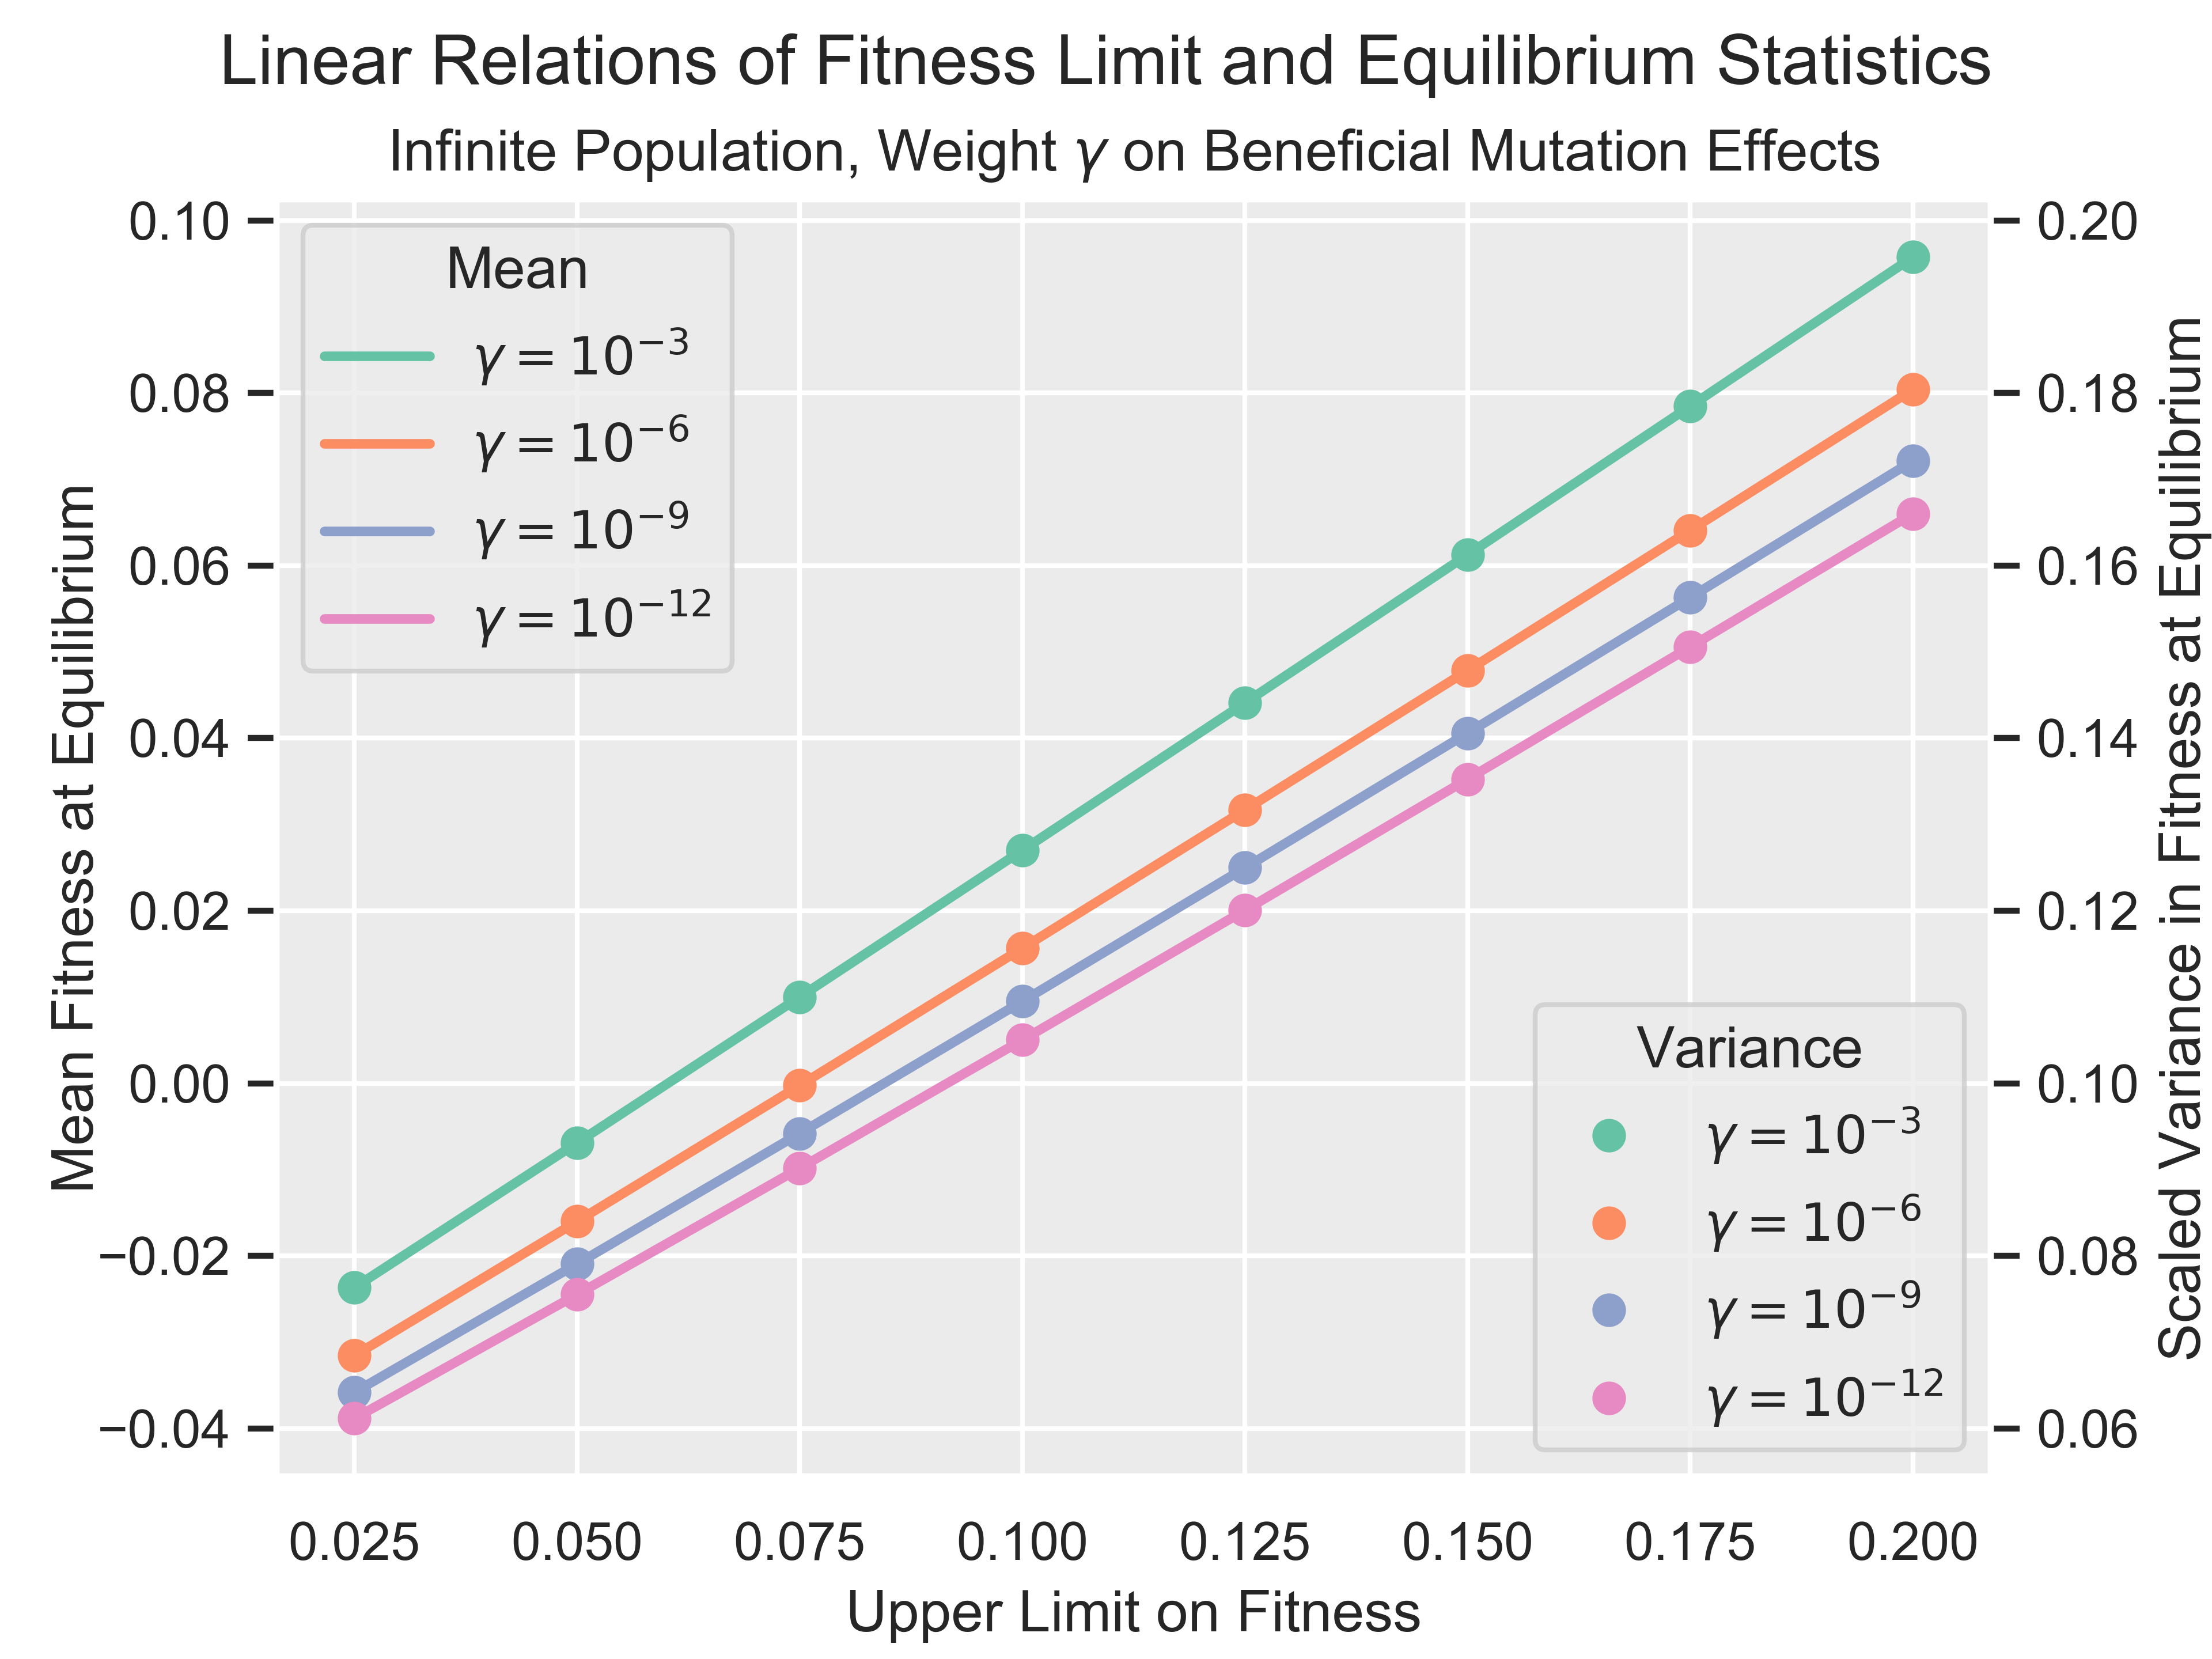

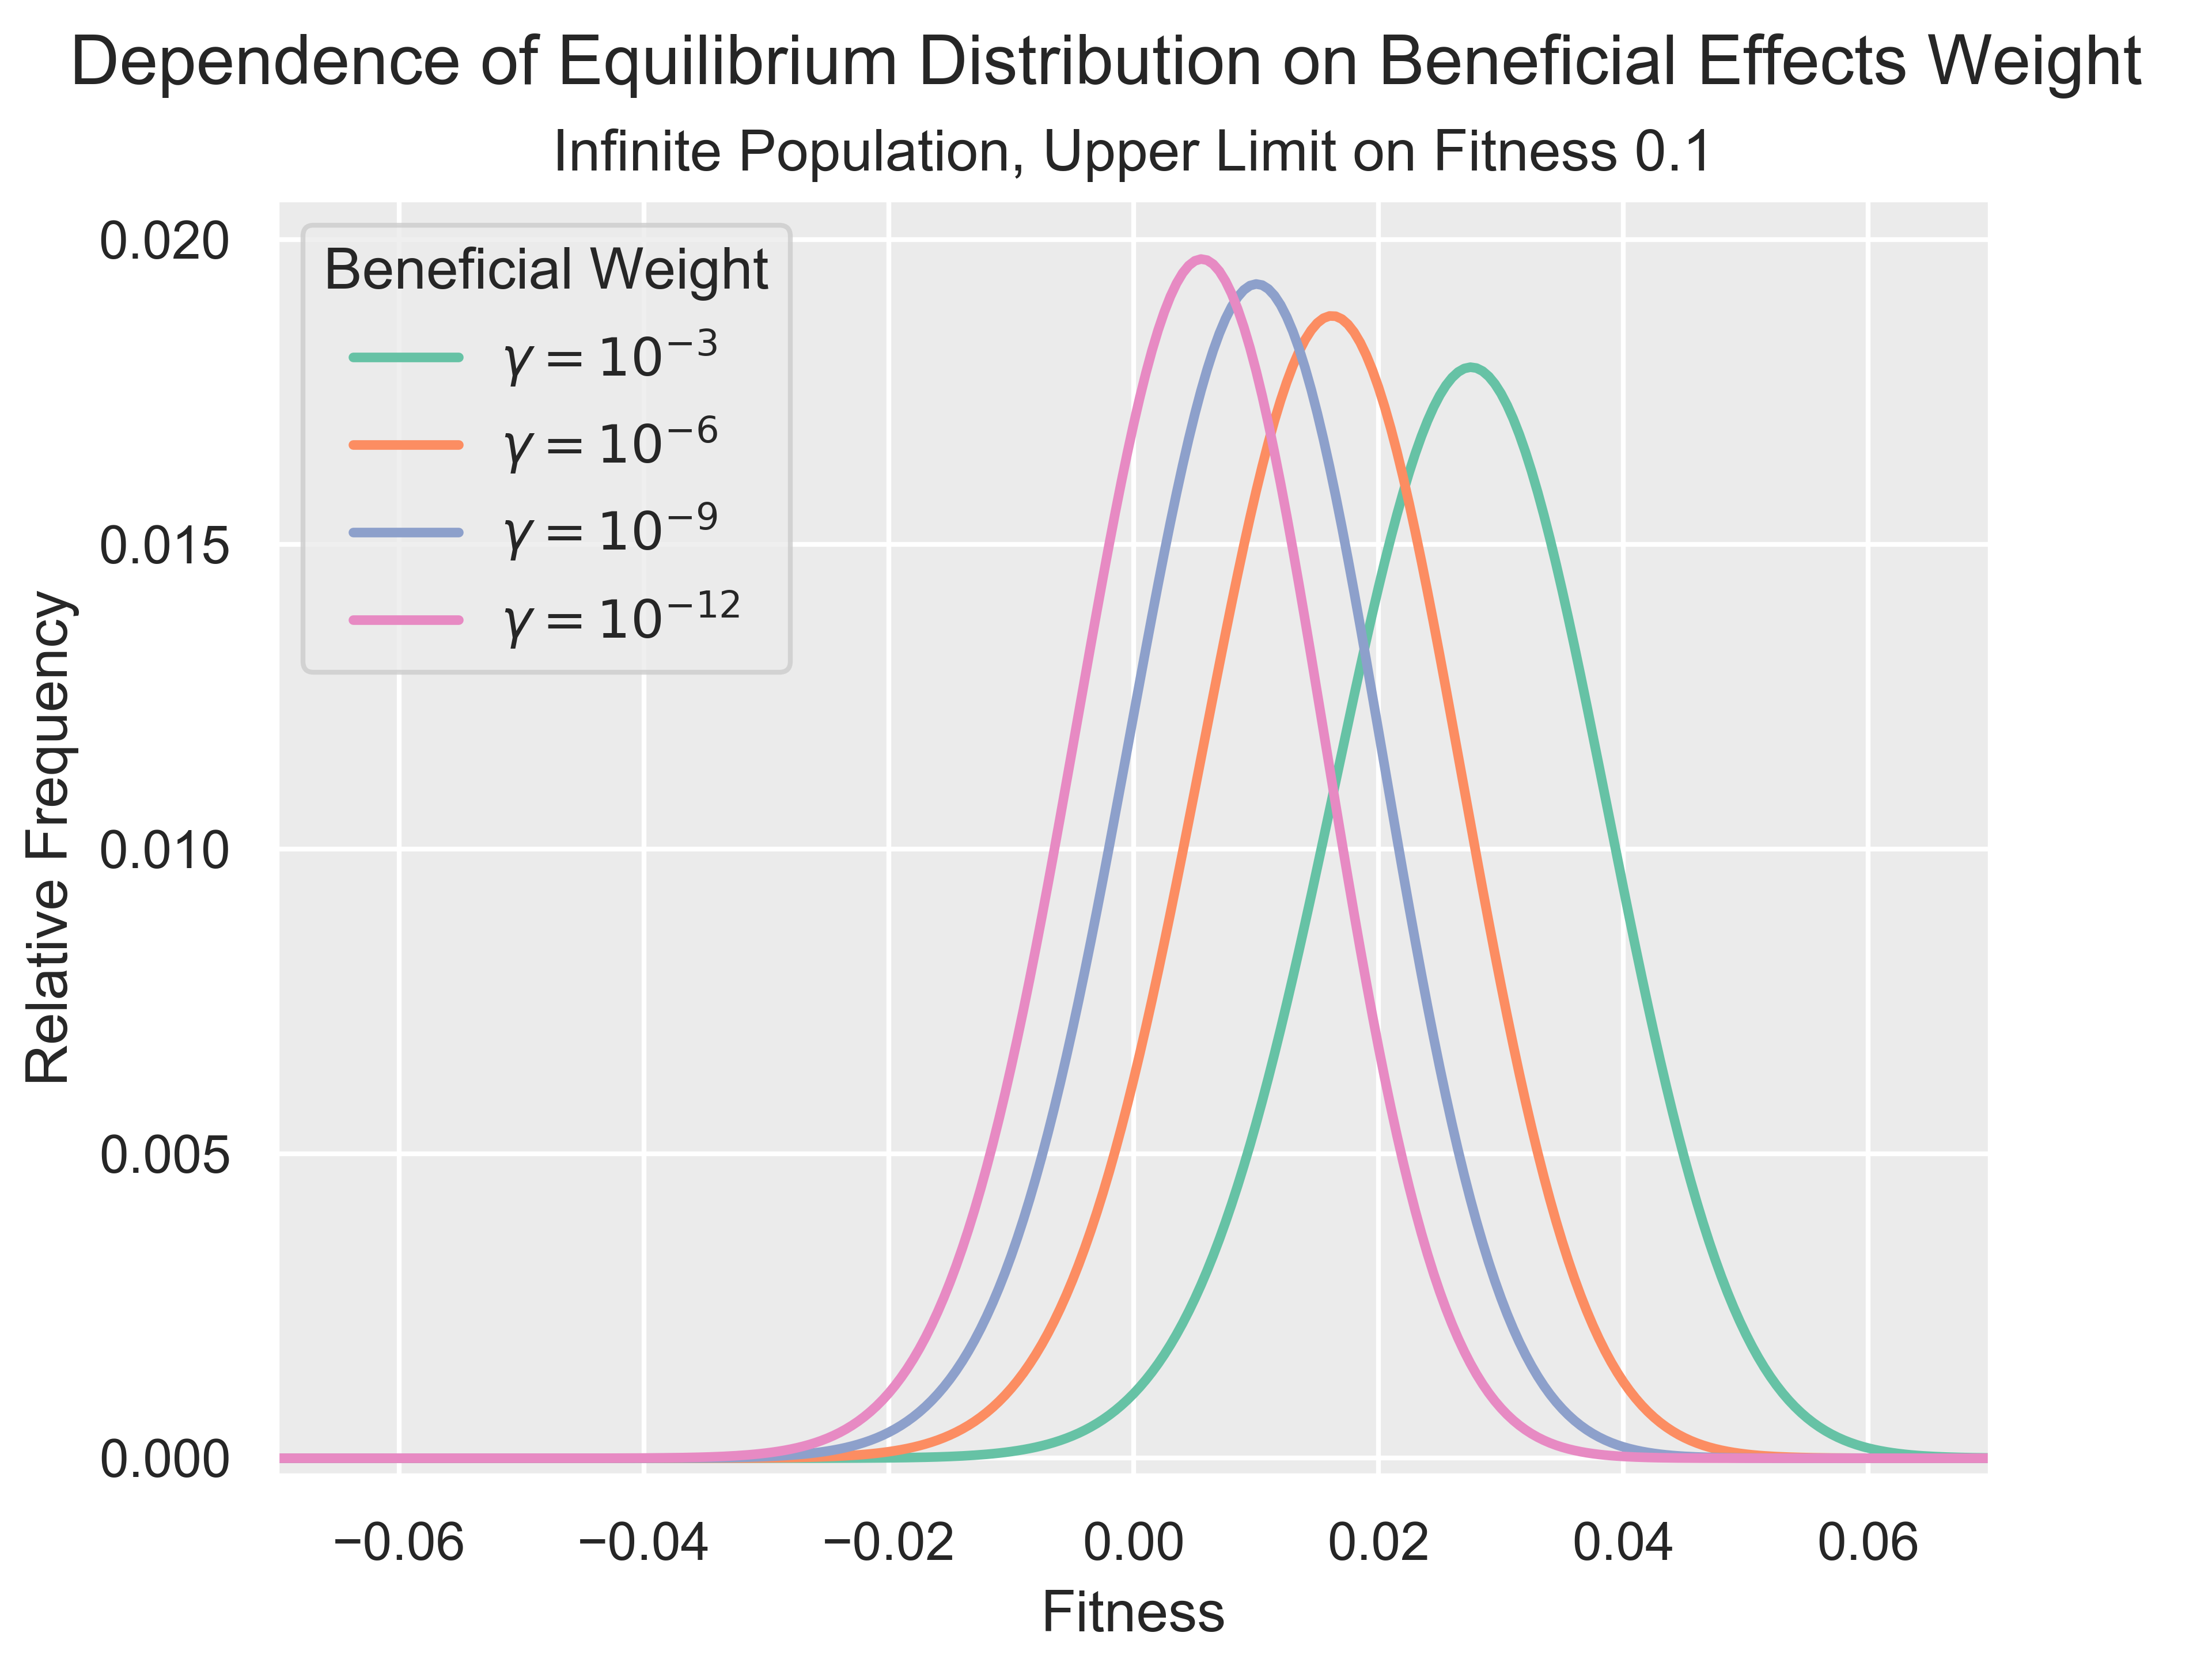

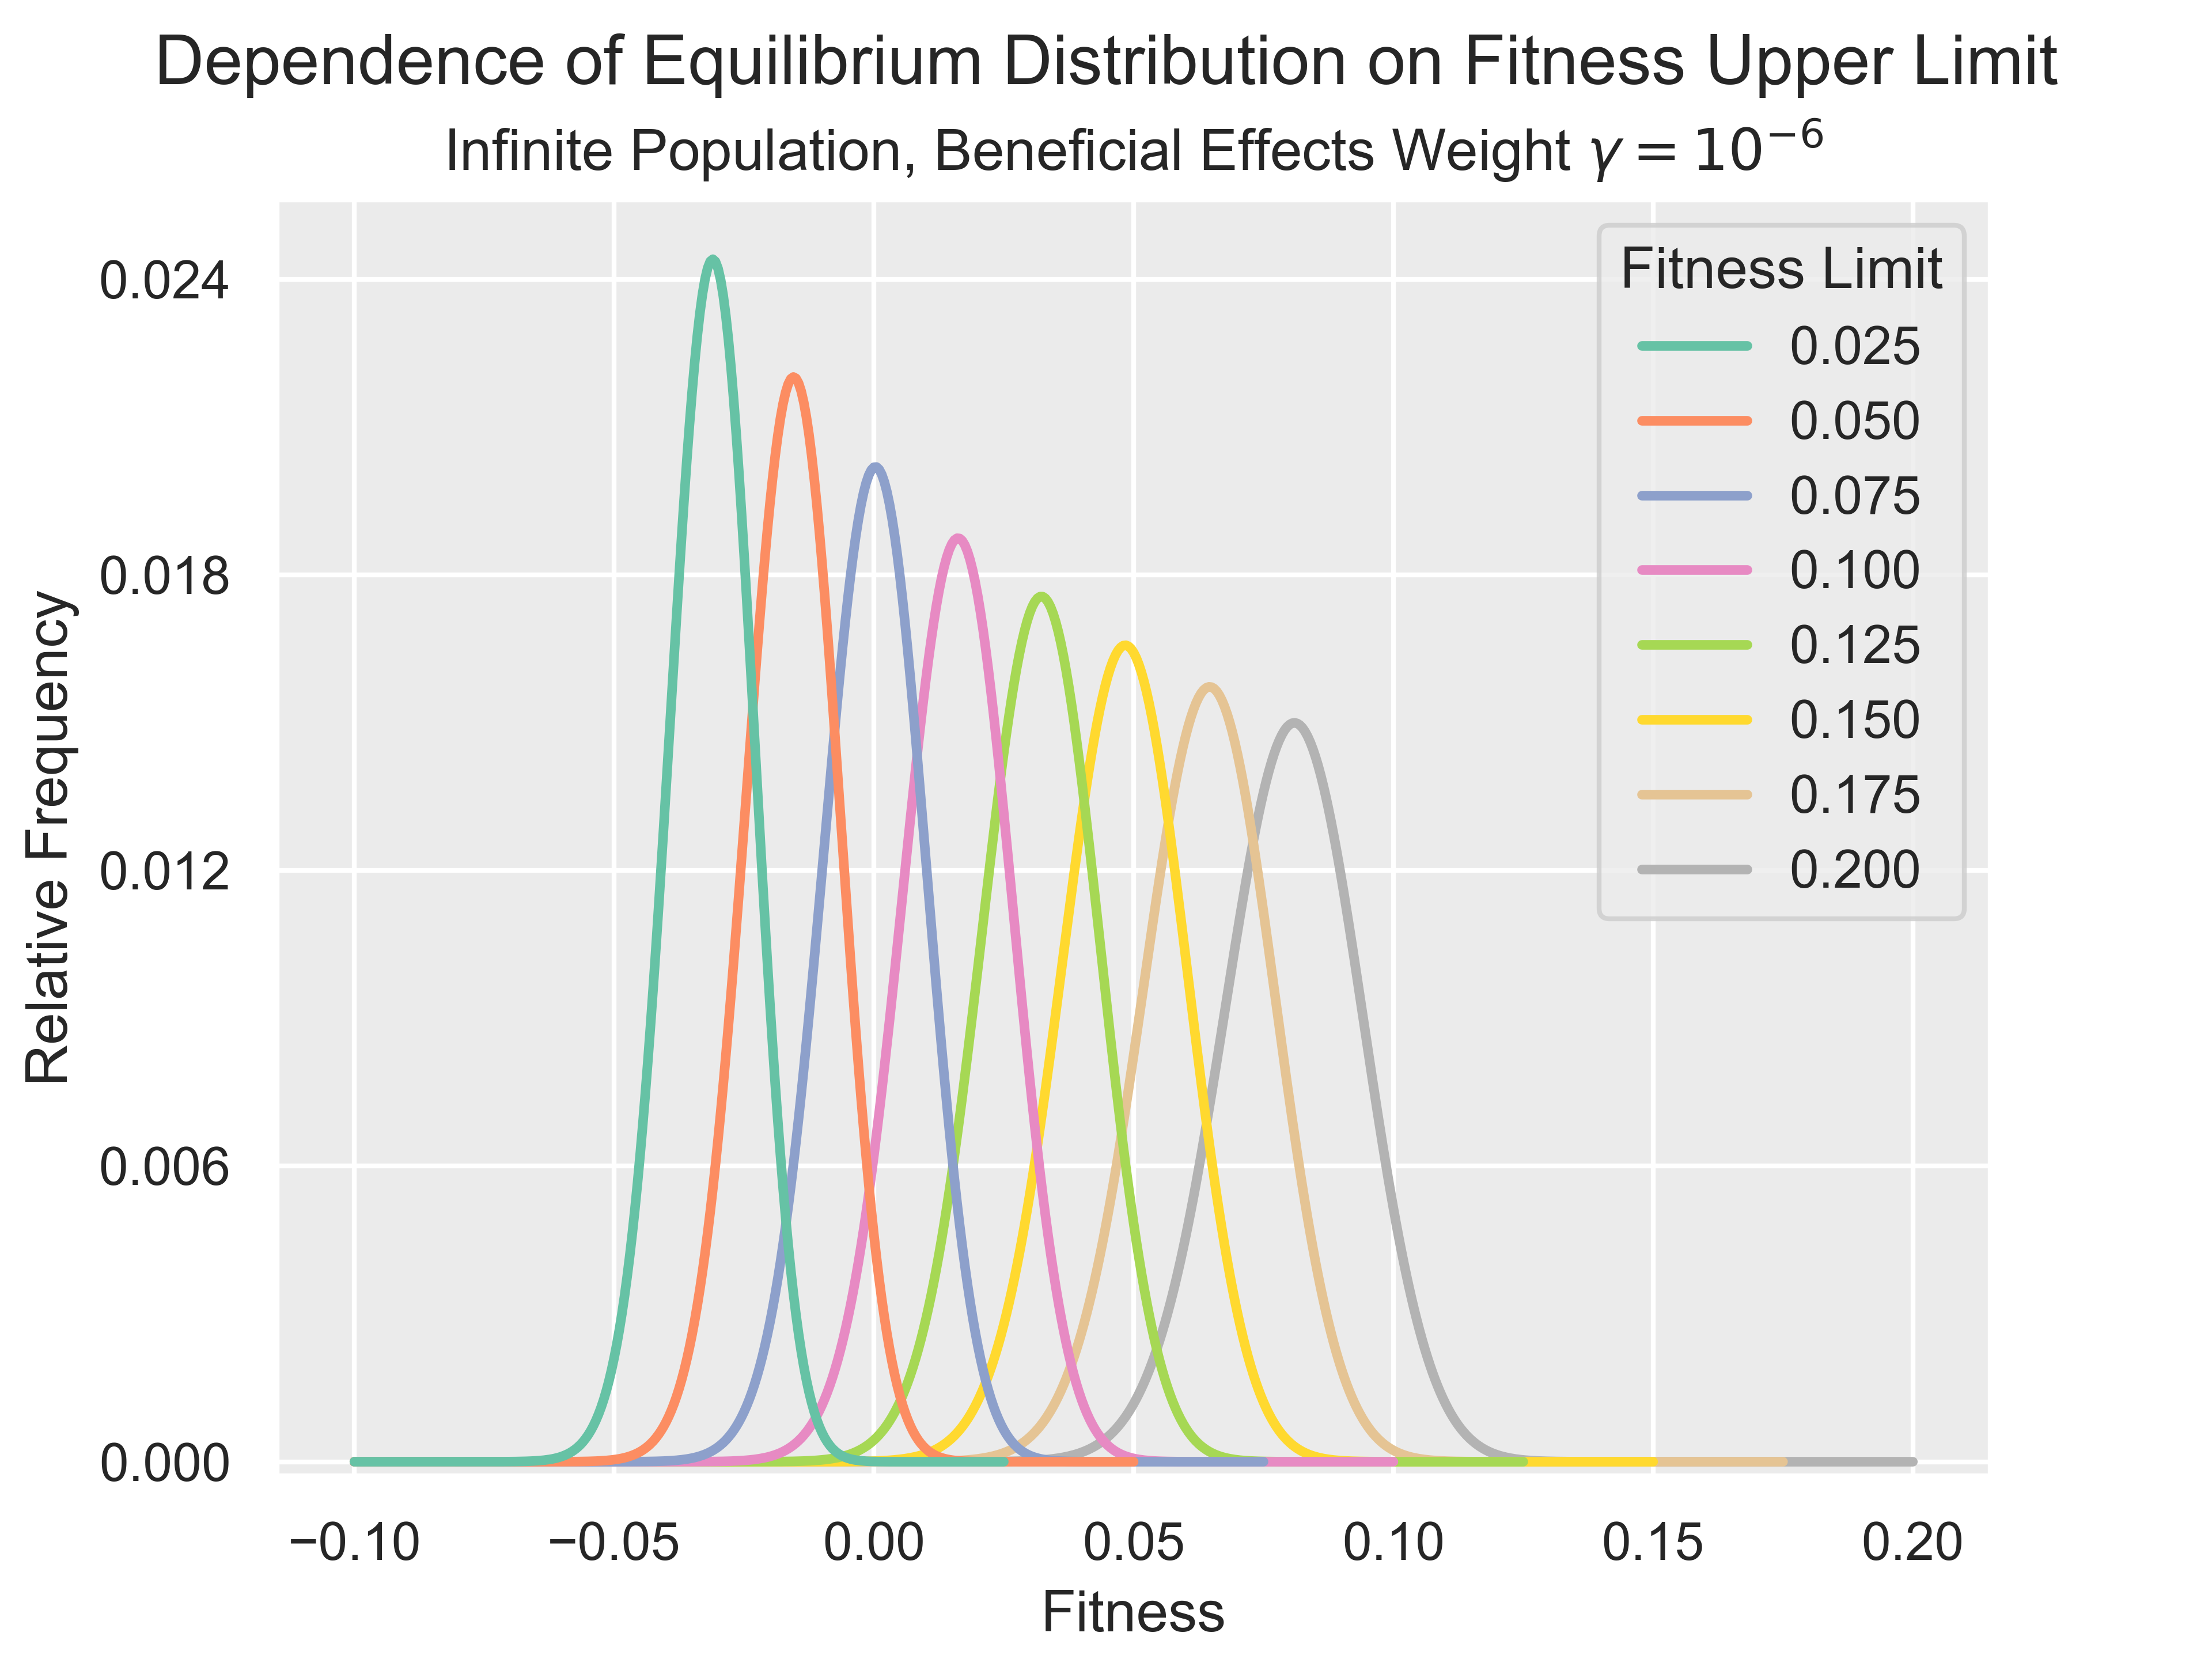

In [12]:
"""
Generate Figure 3 of the article.
"""
eq.plot_stats(
    'Linear Relations of Fitness Limit and Equilibrium Statistics',
    'Infinite Population, Weight $\gamma$ on Beneficial Mutation Effects')
eq.ax_mean.yaxis.set_label_coords(-0.1, 0.5)
eq.save_and_display(DIR + 'Fig3.png')

"""
Generate Figure 4 of the article.
"""
eq.plot_column(3)
eq.ax.set_xlim([-0.07, 0.07])
t = 'Dependence of Equilibrium Distribution on Beneficial Effects Weight'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig4.png')

"""
Generate Figure 5 of the article.
"""
eq.plot_row(1)
t = 'Dependence of Equilibrium Distribution on Fitness Upper Limit'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig5.png')

In [13]:
def regression_report(log_weights, fitness_limits):
    def print_results(regression, log_weight):
        print('Beneficial weight 10^{}'.format(log_weight))
        print('\tslope       :', regress.slope)
        print('\tintercept   :', regress.intercept)
        print('\tcorrelation :', regress.rvalue)

    print('Linear regression of mean on variance')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(eq.var[i], eq.mean[i])
        print_results(regress, log_weight)

    print('\nLinear regression of variance on max fitness')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(fitness_limits, eq.var[i])
        print_results(regress, log_weight)

regression_report(log_weights, eq.limits.astype(float))

Linear regression of mean on variance
Beneficial weight 10^-3
	slope       : 1019.1015858424515
	intercept   : -0.10000000002365514
	correlation : 1.0
Beneficial weight 10^-6
	slope       : 1017.0654166266036
	intercept   : -0.09999999999606757
	correlation : 1.0
Beneficial weight 10^-9
	slope       : 1017.0633844482369
	intercept   : -0.09999999998492959
	correlation : 0.9999999999999998
Beneficial weight 10^-12
	slope       : 1017.063382231312
	intercept   : -0.09999999996080838
	correlation : 1.0

Linear regression of variance on max fitness
Beneficial weight 10^-3
	slope       : 0.0006698581425665232
	intercept   : 5.7844500573204493e-05
	correlation : 0.9999883243233325
Beneficial weight 10^-6
	slope       : 0.0006294379976519807
	intercept   : 5.1089104397580965e-05
	correlation : 0.9999691024049321
Beneficial weight 10^-9
	slope       : 0.0006069860811202147
	intercept   : 4.736126631334164e-05
	correlation : 0.9999497252879908
Beneficial weight 10^-12
	slope       : 0.000589741

**Scrap.** Throughout, the bin width $w$ and death rate $d$ are held at 0.0005 and 0.1, respectively. When we specify an upper limit $m_\text{max}$ on fitness, the upper limit is, like the death rate, an integer multiple of the bin width, and the number of bins (classes of organism) is

$$N = \frac{m_\text{max} + d}{w} + 1.$$

In [22]:
"""
Indicate when this code cell was last executed.
"""
from datetime import datetime
print("Time stamp:", datetime.now())

Time stamp: 2020-03-02 18:38:23.973607
